In [1]:
!pip install yfinance
!pip install --upgrade --force-reinstall numpy pandas

  Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_x86_64.whl.metadata (60 kB)
  Using cached pandas-2.3.3-cp39-cp39-macosx_10_9_x86_64.whl.metadata (91 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_x86_64.whl (6.9 MB)
Using cached pandas-2.3.3-cp39-cp39-macosx_10_9_x86_64.whl (11.6 MB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached pytz-2026.2-py2.py3-none-any.whl (510 kB)
Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)
  Attempting uninstall: pytz
    Found existing installation: pytz 2026.2
    Uninstalling pytz-2026.2:
      Successfully uninstalled pytz-2026.2
  Attempting uninstall: tzdata━━━━━━━━━━━━━━━━

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

In [3]:
ticker_code = 'AAPL'
data = yf.download(ticker_code, period='5y', interval='1d')
apple = yf.Ticker(ticker_code)
df_apple = apple.history(start='2026-06-01', end='2026-06-30')
df = pd.read_csv("aapl.csv", header=[0, 1], index_col=0, parse_dates=True)
prices = df[("Close", "AAPL")]
df_apple.head()

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-06-01 00:00:00-04:00,309.630005,310.940002,305.019989,306.309998,48849900,0.0,0.0
2026-06-02 00:00:00-04:00,307.459991,315.450012,306.690002,315.200012,44534700,0.0,0.0
2026-06-03 00:00:00-04:00,314.179993,316.940002,308.850006,310.260010,50836700,0.0,0.0
2026-06-04 00:00:00-04:00,313.230011,313.540009,309.649994,311.230011,44869100,0.0,0.0
2026-06-05 00:00:00-04:00,312.859985,315.170013,307.149994,307.339996,65310500,0.0,0.0


In [4]:
data.to_csv("aapl.csv")
df_apple.to_csv("aapl_data.csv")

## 特徴量エンジニアリング

In [5]:
idx = pd.IndexSlice

In [31]:
# 外れ値カットのための閾値を設定
outlier_cutoff = 0.01  # 上位1%と下位1%を外れ値として除外
data = pd.DataFrame(index=prices.index)
lags = [1, 5, 21, 63, 252] # 1日、5日、21日、63日、252日のラグを設定

for lag in lags:
    returns = prices.pct_change(lag)
    returns = returns.clip(lower=returns.quantile(outlier_cutoff),
                           upper=returns.quantile(1 - outlier_cutoff))
    data[f'return_{lag}d'] = (1 + returns)**(1 / lag) - 1
data_clean = data.dropna()

In [32]:
# デイリーリターンのラグを作成
for t in range(1, 5):
    data_clean[f'return_1d_t-{t}'] = data_clean.return_1d.shift(t)

/var/folders/0t/4k_fnjgx3xx3g82tw0xkph540000gn/T/ipykernel_71474/4156970819.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean[f'return_1d_t-{t}'] = data_clean.return_1d.shift(t)
/var/folders/0t/4k_fnjgx3xx3g82tw0xkph540000gn/T/ipykernel_71474/4156970819.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean[f'return_1d_t-{t}'] = data_clean.return_1d.shift(t)
/var/folders/0t/4k_fnjgx3xx3g82tw0xkph540000gn/T/ipykernel_71474/4156970819.py:3: SettingWithCopyWarning: 
A value is trying to be

In [33]:
# モメンタムの計算
# Stefan Jansen氏の書籍に記載されているコード
for lag in [5, 21, 63, 252]:
    data_clean[f'momentum_{lag}d'] = data_clean[f'return_{lag}d'] - data_clean['return_1d']

data_clean[f'momentum_5_21d'] = data_clean[f'momentum_21d'].sub(data_clean['return_5d'], axis=0)
data_clean[f'momentum_5_63d'] = data_clean[f'momentum_63d'].sub(data_clean['return_5d'], axis=0)
data_clean[f'momentum_21_252d'] = data_clean[f'momentum_252d'].sub(data_clean['return_21d'], axis=0)

/var/folders/0t/4k_fnjgx3xx3g82tw0xkph540000gn/T/ipykernel_71474/113617117.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean[f'momentum_{lag}d'] = data_clean[f'return_{lag}d'] - data_clean['return_1d']
/var/folders/0t/4k_fnjgx3xx3g82tw0xkph540000gn/T/ipykernel_71474/113617117.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean[f'momentum_{lag}d'] = data_clean[f'return_{lag}d'] - data_clean['return_1d']
/var/folders/0t/4k_fnjgx3xx3g82tw0xkph540000gn/T/ipykernel_71474/113617117.py:4: S

In [34]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1002 entries, 2022-07-01 to 2026-06-30
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   return_1d         1002 non-null   float64
 1   return_5d         1002 non-null   float64
 2   return_21d        1002 non-null   float64
 3   return_63d        1002 non-null   float64
 4   return_252d       1002 non-null   float64
 5   return_1d_t-1     1001 non-null   float64
 6   return_1d_t-2     1000 non-null   float64
 7   return_1d_t-3     999 non-null    float64
 8   return_1d_t-4     998 non-null    float64
 9   momentum_5d       1002 non-null   float64
 10  momentum_21d      1002 non-null   float64
 11  momentum_63d      1002 non-null   float64
 12  momentum_252d     1002 non-null   float64
 13  momentum_5_21d    1002 non-null   float64
 14  momentum_5_63d    1002 non-null   float64
 15  momentum_21_252d  1002 non-null   float64
dtypes: float64(16)
memory us

In [35]:
type(prices)

pandas.core.series.Series

In [36]:
print(data_clean.head())

            return_1d  return_5d  return_21d  return_63d  return_252d  \
Date                                                                    
2022-07-01   0.016164  -0.003884   -0.003234   -0.003468     0.000070   
2022-07-05   0.018930  -0.000141   -0.003135   -0.003275     0.000068   
2022-07-06   0.009607   0.007850   -0.000812   -0.003468     0.000048   
2022-07-07   0.024000   0.010025    0.000068   -0.002816     0.000071   
2022-07-08   0.004714   0.014660   -0.000538   -0.002447     0.000127   

            return_1d_t-1  return_1d_t-2  return_1d_t-3  return_1d_t-4  \
Date                                                                     
2022-07-01            NaN            NaN            NaN            NaN   
2022-07-05       0.016164            NaN            NaN            NaN   
2022-07-06       0.018930       0.016164            NaN            NaN   
2022-07-07       0.009607       0.018930       0.016164            NaN   
2022-07-08       0.024000       0.009607    

In [55]:
# カレンダー特徴量
data_clean['presidental_cycle'] = (data_clean.index.year) % 4 == 0

/var/folders/0t/4k_fnjgx3xx3g82tw0xkph540000gn/T/ipykernel_71474/2015055098.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean['presidental_cycle'] = (data_clean.index.year) % 4 == 0


In [56]:
def volatility(returns, risk_free_rate=0.0, n=252):
    return np.std(returns, ddof=1) * np.sqrt(n)

returns = prices.pct_change()
windows = [5, 21, 63, 252]

for window in windows:
    data_clean[f'volatility_{window}d'] = returns.rolling(window=window).apply(volatility, raw=True)

/var/folders/0t/4k_fnjgx3xx3g82tw0xkph540000gn/T/ipykernel_71474/413331884.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean[f'volatility_{window}d'] = returns.rolling(window=window).apply(volatility, raw=True)


In [57]:
data_clean.to_csv("feature_dataset.csv")

# 時系列用CV設計

In [58]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5, test_size=60, gap=1)
for i, (train_index, test_index) in enumerate(tscv.split(data)):
    print(f'Fold {i+1}: Train indices {train_index}, Test indices {test_index}')

Fold 1: Train indices [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 

* naive_up:常に上昇と予測
* persist: 前日に同じ方向を予測
* logostic: 標準化 + ロジスティック回帰

In [59]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

# ターゲット（翌日の上昇/下落を0/1で表す）と翌日リターンを同じ行に揃えてからNaNを落とす
target = (data['return_1d'].shift(-1) > 0).astype(int)
next_day_return_full = data['return_1d'].shift(-1)

model_data = data.assign(target=target, next_day_return=next_day_return_full).iloc[:-1].dropna()
X = model_data.drop(columns=['target', 'next_day_return'])
y = model_data['target']
next_day_return = model_data['next_day_return']

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=0.1))

rows = []
for i, (train_index, test_index) in enumerate(tscv.split(X)):
    model.fit(X.iloc[train_index], y.iloc[train_index])
    y_pred = model.predict(X.iloc[test_index])
    proba = model.predict_proba(X.iloc[test_index])[:, 1]

    naive_up = np.ones(len(test_index), dtype=int)
    persist = (X['return_1d'].iloc[test_index] > 0).astype(int)

    ret = next_day_return.iloc[test_index]
    strat_ret = np.where(y_pred == 1, ret, -ret)
    sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(252)
    bh_sharpe = ret.mean() / ret.std() * np.sqrt(252)

    rows.append({
        'fold': i,
        'acc_logistic': accuracy_score(y.iloc[test_index], y_pred),
        'acc_naive_up': accuracy_score(naive_up, y.iloc[test_index]),
        'acc_persist': accuracy_score(persist, y.iloc[test_index]),
        'auc': roc_auc_score(y.iloc[test_index], proba),
        'f1': f1_score(y.iloc[test_index], y_pred),
        'sharpe_strategy': sharpe,
        'sharpe_buyhold': bh_sharpe,
    })

results = pd.DataFrame(rows).set_index(('fold')).round(4)
results.loc['mean'] = results.mean()
results

,acc_logistic,acc_naive_up,acc_persist,auc,f1,sharpe_strategy,sharpe_buyhold
fold,,,,,,,
0,0.6000,0.58330,0.56670,0.59540,0.73330,0.89130,0.94210
1,0.5000,0.50000,0.55000,0.59890,0.66670,3.31280,3.28500
2,0.5833,0.53330,0.56670,0.57480,0.70590,2.82330,0.85440
3,0.5167,0.51670,0.55000,0.58180,0.64200,1.85720,-0.24080
4,0.5000,0.53330,0.36670,0.37170,0.37500,-1.08180,2.35760
mean,0.5400,0.53332,0.52002,0.54452,0.62458,1.56056,1.43966


# 可視化: Foldごとの的中率比較

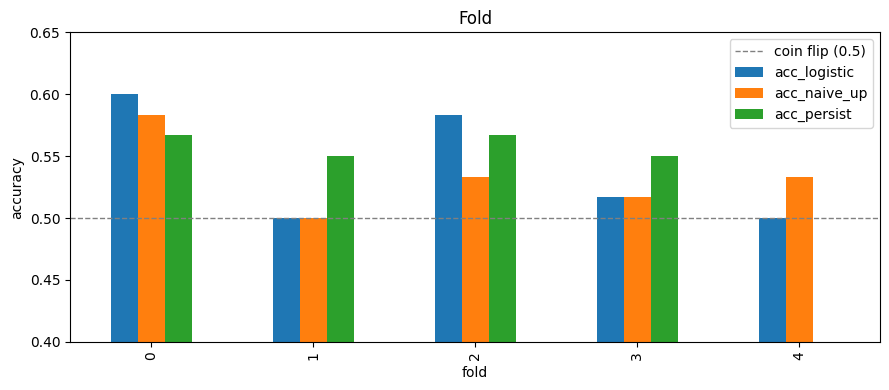

In [60]:
import matplotlib.pyplot as plt

ax = results.drop(index='mean')[['acc_logistic', 'acc_naive_up', 'acc_persist']].plot.bar(figsize=(9, 4))
ax.axhline(0.5, color='gray', ls='--', lw=1, label='coin flip (0.5)')
ax.set_ylabel('accuracy'); ax.set_ylim(0.4, 0.65); ax.legend()
ax.set_title('Fold')
plt.tight_layout(); plt.show()